In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 🎬 Netflix Customer Churn Prediction

## Objective
The goal of this project is to build a machine learning model to predict whether a customer will churn from a Netflix-like streaming platform based on behavioral, demographic, and subscription-related features.

Customer churn prediction helps businesses identify at-risk users and take proactive retention actions.

In [3]:
import pandas as pd
import numpy as np
df = pd.read_excel(r"C:\Users\Administrator\Desktop\Netflix\Data\netflix_large_user_data.xlsx")
print(df.head())

  Customer ID  Subscription Length (Months)  \
0      C00001                            12   
1      C00002                            12   
2      C00003                             3   
3      C00004                             3   
4      C00005                            24   

   Customer Satisfaction Score (1-10)  Daily Watch Time (Hours)  \
0                                  10                      4.85   
1                                   8                      1.75   
2                                   4                      2.75   
3                                   7                      3.00   
4                                   2                      1.37   

   Engagement Rate (1-10) Device Used Most Often Genre Preference  \
0                       4                 Tablet           Action   
1                       9                 Laptop         Thriller   
2                       9               Smart TV           Comedy   
3                       9             

In [4]:
df.shape

(1000, 16)

# EDA

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Customer ID                         1000 non-null   object 
 1   Subscription Length (Months)        1000 non-null   int64  
 2   Customer Satisfaction Score (1-10)  1000 non-null   int64  
 3   Daily Watch Time (Hours)            1000 non-null   float64
 4   Engagement Rate (1-10)              1000 non-null   int64  
 5   Device Used Most Often              1000 non-null   object 
 6   Genre Preference                    1000 non-null   object 
 7   Region                              1000 non-null   object 
 8   Payment History (On-Time/Delayed)   1000 non-null   object 
 9   Subscription Plan                   1000 non-null   object 
 10  Churn Status (Yes/No)               1000 non-null   object 
 11  Support Queries Logged              1000 non

In [6]:
df.describe()


,Subscription Length (Months),Customer Satisfaction Score (1-10),Daily Watch Time (Hours),Engagement Rate (1-10),Support Queries Logged,Age,Monthly Income ($),Promotional Offers Used,Number of Profiles Created
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,9.17700,5.379000,2.829420,5.511000,4.951000,43.840000,5251.452000,2.422000,2.937000
std,8.21859,2.856487,1.302673,2.871607,3.111636,15.356439,2720.859072,1.689607,1.430062
min,1.00000,1.000000,0.500000,1.000000,0.000000,18.000000,510.000000,0.000000,1.000000
25%,3.00000,3.000000,1.650000,3.000000,2.000000,30.000000,3073.250000,1.000000,2.000000
50%,6.00000,5.000000,2.890000,6.000000,5.000000,44.000000,5286.000000,2.000000,3.000000
75%,12.00000,8.000000,3.932500,8.000000,8.000000,57.000000,7598.250000,4.000000,4.000000
max,24.00000,10.000000,5.000000,10.000000,10.000000,70.000000,9994.000000,5.000000,5.000000


In [7]:
df.isnull().sum()

Customer ID                           0
Subscription Length (Months)          0
Customer Satisfaction Score (1-10)    0
Daily Watch Time (Hours)              0
Engagement Rate (1-10)                0
Device Used Most Often                0
Genre Preference                      0
Region                                0
Payment History (On-Time/Delayed)     0
Subscription Plan                     0
Churn Status (Yes/No)                 0
Support Queries Logged                0
Age                                   0
Monthly Income ($)                    0
Promotional Offers Used               0
Number of Profiles Created            0
dtype: int64

In [8]:

print(df["Churn Status (Yes/No)"].value_counts())

Churn Status (Yes/No)
Yes    539
No     461
Name: count, dtype: int64


In [9]:
print(df.head())


  Customer ID  Subscription Length (Months)  \
0      C00001                            12   
1      C00002                            12   
2      C00003                             3   
3      C00004                             3   
4      C00005                            24   

   Customer Satisfaction Score (1-10)  Daily Watch Time (Hours)  \
0                                  10                      4.85   
1                                   8                      1.75   
2                                   4                      2.75   
3                                   7                      3.00   
4                                   2                      1.37   

   Engagement Rate (1-10) Device Used Most Often Genre Preference  \
0                       4                 Tablet           Action   
1                       9                 Laptop         Thriller   
2                       9               Smart TV           Comedy   
3                       9             

# visualization

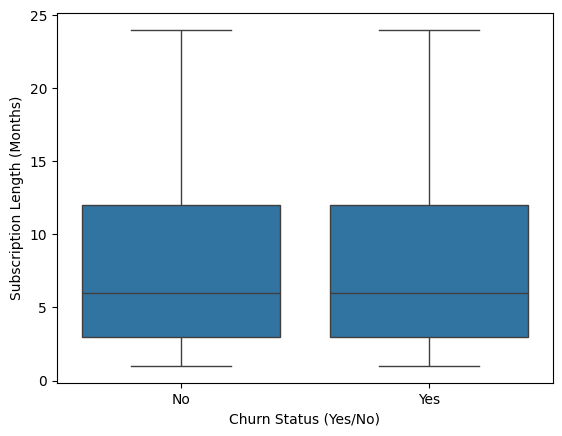

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(x='Churn Status (Yes/No)', y='Subscription Length (Months)', data=df)
plt.show()

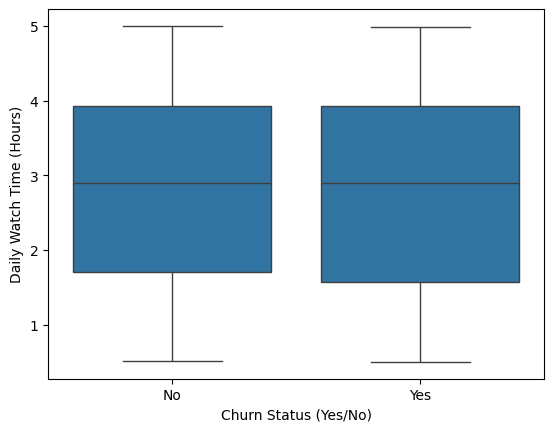

In [11]:
sns.boxplot(x='Churn Status (Yes/No)', y='Daily Watch Time (Hours)', data=df)
plt.show()

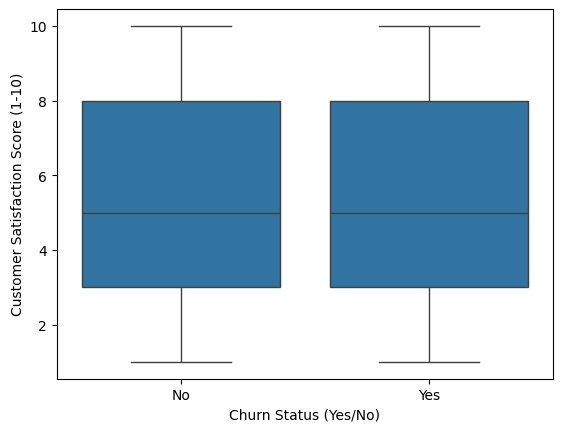

In [12]:
sns.boxplot(x='Churn Status (Yes/No)', y='Customer Satisfaction Score (1-10)', data=df)
plt.show()

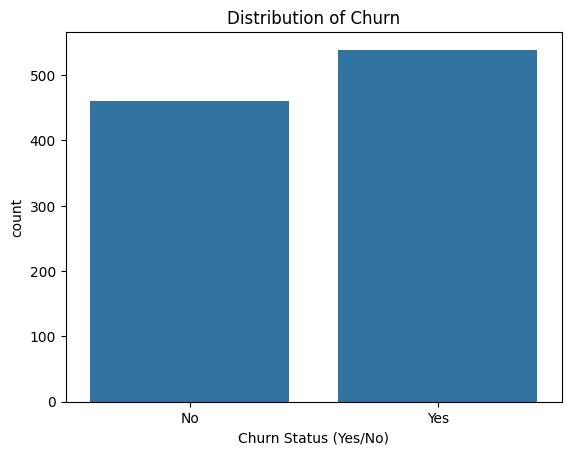

Churn Status (Yes/No)
Yes    0.539
No     0.461
Name: proportion, dtype: float64


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="Churn Status (Yes/No)", data=df)
plt.title("Distribution of Churn")
plt.show()
print(df["Churn Status (Yes/No)"].value_counts(normalize=True))

In [14]:
numerical_cols = df.select_dtypes(include=["int64","float64"]).columns.tolist()
categorical_cols= df.select_dtypes(include=["object"]).columns.tolist()
print("numerical columns", numerical_cols)
print("categorical_cols", categorical_cols)

numerical columns ['Subscription Length (Months)', 'Customer Satisfaction Score (1-10)', 'Daily Watch Time (Hours)', 'Engagement Rate (1-10)', 'Support Queries Logged', 'Age', 'Monthly Income ($)', 'Promotional Offers Used', 'Number of Profiles Created']
categorical_cols ['Customer ID', 'Device Used Most Often', 'Genre Preference', 'Region', 'Payment History (On-Time/Delayed)', 'Subscription Plan', 'Churn Status (Yes/No)']


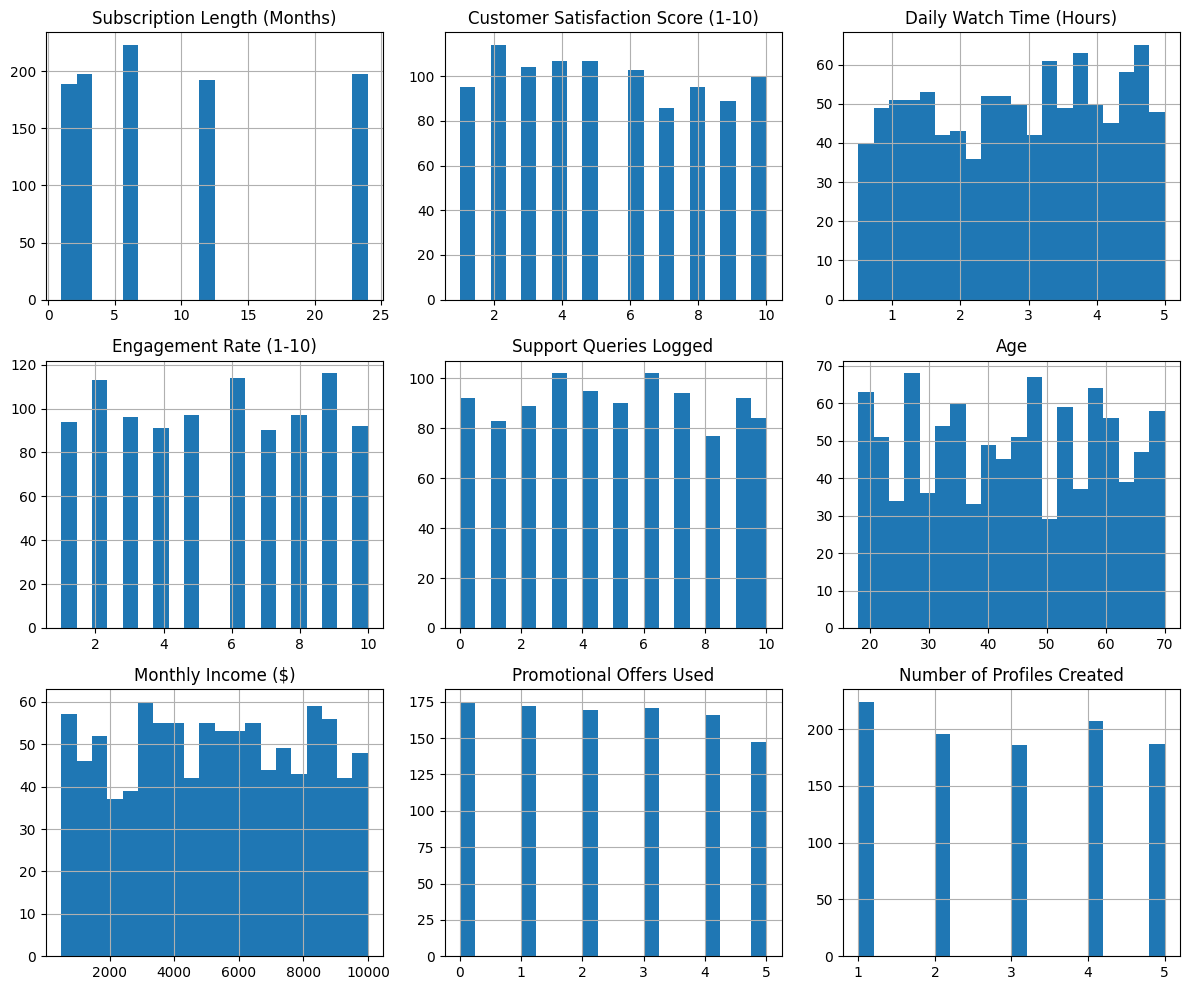

In [15]:
df[numerical_cols].hist(figsize=(12,10), bins=20)
plt.tight_layout()
plt.show()

In [16]:
# for col in categorical_cols:
#     plt.figure(figsize=(6,4))
#     sns.countplot(x=col, hue="Churn Status (yes/No)", data=df)
#     plt.xticks(rotation=45)
#     plt.title(f"{col}/ vs Churn")
#     plt.tight_layout()
#     plt.show()

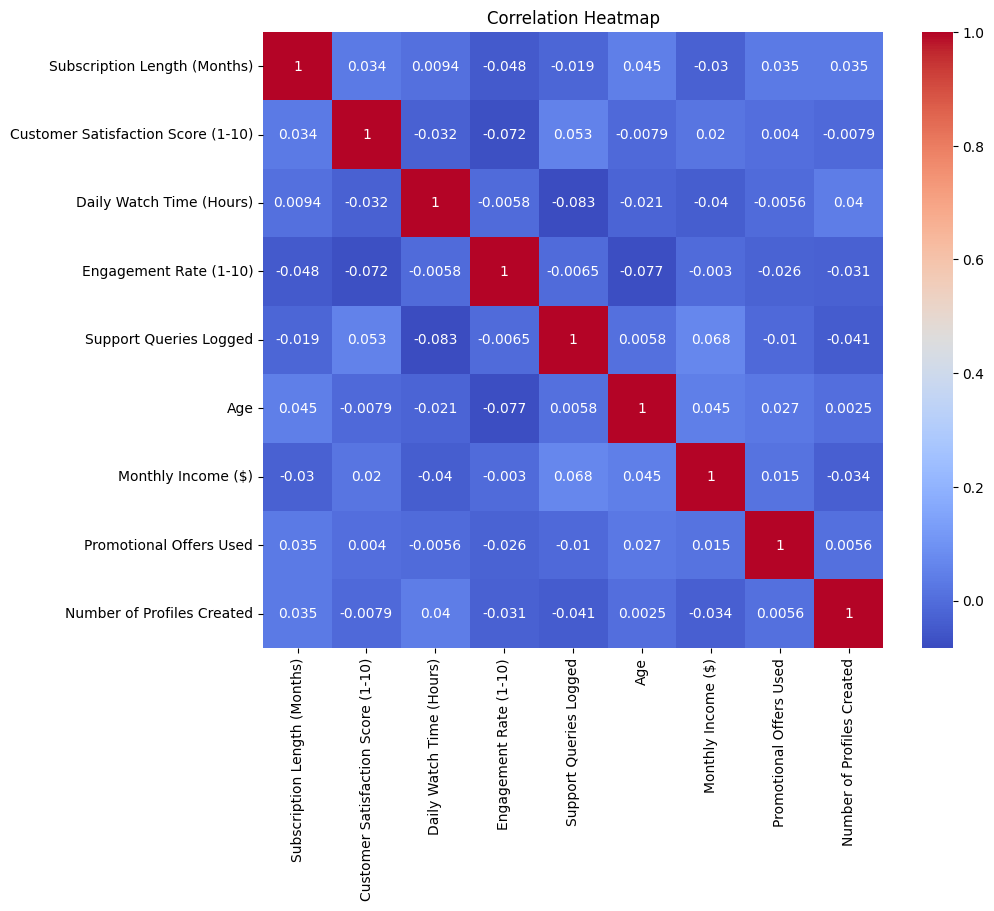

In [17]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## 🔗 Correlation Analysis – Key Insight

The correlation heatmap shows that most numerical features have **very weak correlations** with each other and with the target variable (Churn).

### Key Observations
- Correlation values are close to **zero**, indicating weak linear relationships.
- No strong multicollinearity exists among features.
- No single feature strongly explains customer churn.

### Insight
This suggests that churn behavior is influenced by **multiple interacting factors** rather than a single variable. Therefore, a nonlinear ensemble model such as Random Forest is appropriate for capturing complex relationships in the data.

In [18]:
df = df.drop("Customer ID", axis=1)

In [19]:
df["Churn Status (Yes/No)"] = df["Churn Status (Yes/No)"].map({
    "Yes":1,
    "No":0
})

In [20]:
# List of categorical columns
categorical_cols = [
    "Device Used Most Often",
    "Genre Preference",
    "Region",
    "Payment History (On-Time/Delayed)",
    "Subscription Plan"
]

# Apply One-Hot Encoding
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Check new dataset shape
print(df.shape)

# See first few rows
df.head()

(1000, 27)


,Subscription Length (Months),Customer Satisfaction Score (1-10),Daily Watch Time (Hours),Engagement Rate (1-10),Churn Status (Yes/No),Support Queries Logged,Age,Monthly Income ($),Promotional Offers Used,Number of Profiles Created,...,Genre Preference_Romance,Genre Preference_Sci-Fi,Genre Preference_Thriller,Region_Asia,Region_Europe,Region_North America,Region_South America,Payment History (On-Time/Delayed)_On-Time,Subscription Plan_Premium,Subscription Plan_Standard
0,12,10,4.85,4,0,10,33,6250,5,2,...,False,False,False,False,True,False,False,True,False,False
1,12,8,1.75,9,1,9,28,7018,1,5,...,False,False,True,False,True,False,False,True,False,False
2,3,4,2.75,9,1,3,18,1055,1,5,...,False,False,False,True,False,False,False,True,True,False
3,3,7,3.00,9,0,5,32,6707,5,4,...,False,False,False,False,True,False,False,False,True,False
4,24,2,1.37,5,1,2,59,1506,3,5,...,False,False,False,False,False,True,False,True,False,True


In [21]:
X = df.drop("Churn Status (Yes/No)", axis=1)
y = df["Churn Status (Yes/No)"]

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [23]:
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()

# X_train = scaler.fit_transform(X_train)

# X_test = scaler.transform(X_test)

In [24]:
print(X_train.shape)
print(X_test.shape)

(800, 26)
(200, 26)


In [25]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [26]:

from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.565
              precision    recall  f1-score   support

           0       0.53      0.50      0.51        92
           1       0.59      0.62      0.61       108

    accuracy                           0.56       200
   macro avg       0.56      0.56      0.56       200
weighted avg       0.56      0.56      0.56       200



In [27]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(max_iter=1000,random_state=42)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))

print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.485
              precision    recall  f1-score   support

           0       0.42      0.33      0.37        92
           1       0.52      0.62      0.57       108

    accuracy                           0.48       200
   macro avg       0.47      0.47      0.47       200
weighted avg       0.47      0.48      0.47       200



c:\Users\Administrator\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [28]:
# Predict probabilities
y_prob = log_model.predict_proba(X_test)[:,1]

In [29]:

from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

In [30]:
import numpy as np

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-6)

best_index = np.argmax(f1_scores)

best_threshold = thresholds[best_index]

print("Best Threshold:", best_threshold)

Best Threshold: 0.29862397851134165


In [31]:
y_pred_best = (y_prob > 0.5).astype(int)

In [32]:
print("Classification Report After Threshold Tuning:\n")

print(classification_report(y_test, y_pred_best))

Classification Report After Threshold Tuning:

              precision    recall  f1-score   support

           0       0.42      0.33      0.37        92
           1       0.52      0.62      0.57       108

    accuracy                           0.48       200
   macro avg       0.47      0.47      0.47       200
weighted avg       0.47      0.48      0.47       200



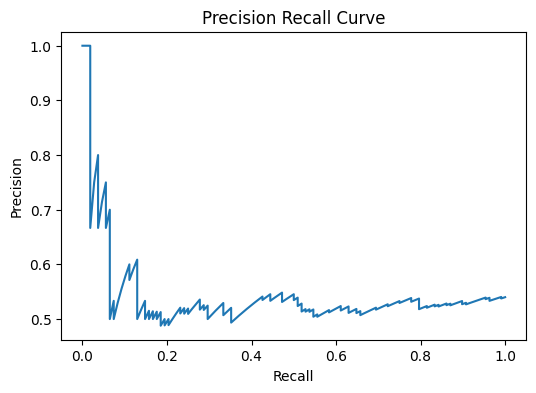

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.plot(recall, precision)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision Recall Curve")

plt.show()

In [34]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

rf_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, rf_prob)

roc_auc = roc_auc_score(y_test, rf_prob)

print("Random Forest ROC AUC:", roc_auc)

Random Forest ROC AUC: 0.5475040257648952


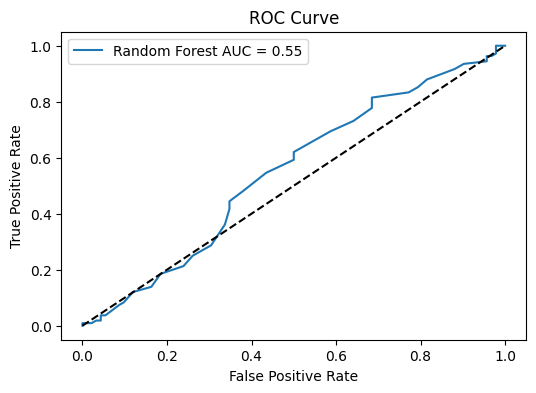

In [35]:
plt.figure(figsize=(6,4))

plt.plot(fpr, tpr, label="Random Forest AUC = " + str(round(roc_auc,2)))

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

In [46]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.54
              precision    recall  f1-score   support

           0       0.50      0.42      0.46        92
           1       0.57      0.64      0.60       108

    accuracy                           0.54       200
   macro avg       0.53      0.53      0.53       200
weighted avg       0.54      0.54      0.54       200



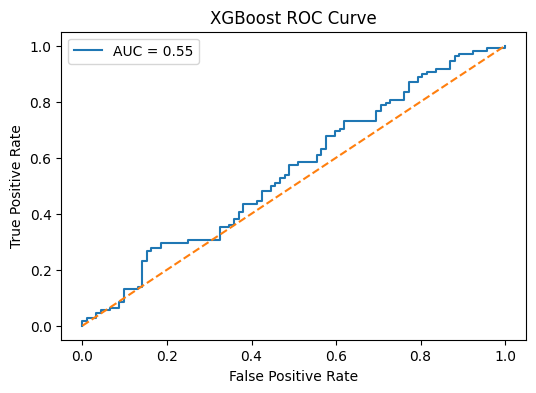

In [47]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_xgb)

roc_auc = roc_auc_score(y_test, y_prob_xgb)

plt.figure(figsize=(6,4))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("XGBoost ROC Curve")

plt.legend()

plt.show()

In [55]:
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations=200,
    learning_rate=0.05,
    depth=4,
    verbose=0
)

cat_model.fit(X_train, y_train)

y_pred_cat = cat_model.predict(X_test)

print("CatBoost Accuracy:", accuracy_score(y_test, y_pred_cat))
print(classification_report(y_test, y_pred_cat))

CatBoost Accuracy: 0.58
              precision    recall  f1-score   support

           0       0.56      0.43      0.49        92
           1       0.59      0.70      0.64       108

    accuracy                           0.58       200
   macro avg       0.57      0.57      0.57       200
weighted avg       0.58      0.58      0.57       200



In [57]:

from sklearn.model_selection import GridSearchCV
from catboost import CatBoostClassifier

param_grid = {
    "iterations": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "depth": [4, 6, 8]
}


cat_model = CatBoostClassifier(verbose=0)

grid = GridSearchCV(
    estimator=cat_model,
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'depth': 6, 'iterations': 200, 'learning_rate': 0.1}


In [58]:
best_cat = grid.best_estimator_

best_cat.fit(X_train, y_train)


CatBoostClassifier(depth=6, iterations=200, learning_rate=0.1, verbose=0)

In [59]:

y_pred_best = best_cat.predict(X_test)

In [61]:
from sklearn.metrics import accuracy_score, classification_report

print("Tuned CatBoost Accuracy:",
      accuracy_score(y_test, y_pred_best))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_best))

Tuned CatBoost Accuracy: 0.54

Classification Report:

              precision    recall  f1-score   support

           0       0.50      0.42      0.46        92
           1       0.57      0.64      0.60       108

    accuracy                           0.54       200
   macro avg       0.53      0.53      0.53       200
weighted avg       0.54      0.54      0.54       200



In [62]:
from sklearn.metrics import roc_auc_score

y_prob_best = best_cat.predict_proba(X_test)[:,1]

print("ROC-AUC Score:",
      roc_auc_score(y_test, y_prob_best))

ROC-AUC Score: 0.5167069243156199
